In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load the local file directly and designate the first unnamed column as the index
df = pd.read_csv('Salary_dataset.csv', index_col=0)

# Display the first 5 rows to check the data structure
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [3]:
print("--- Dataset Shape ---")
print(df.shape)

print("\n--- Column Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Statistical Summary ---")
df.describe()

--- Dataset Shape ---
(30, 2)

--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 720.0 bytes

--- Missing Values ---
YearsExperience    0
Salary             0
dtype: int64

--- Statistical Summary ---


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


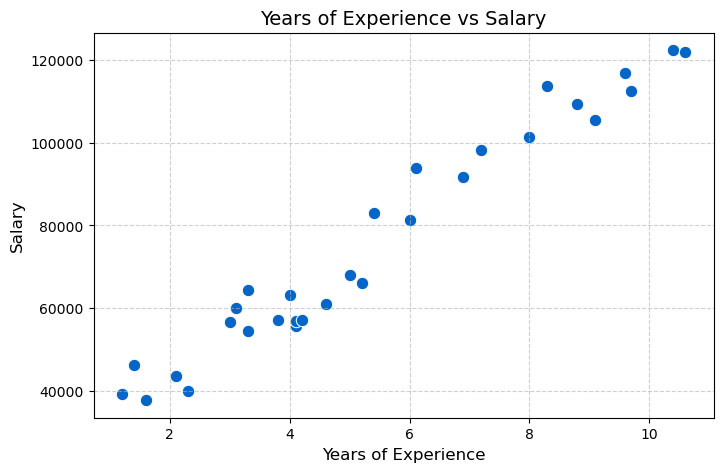

In [4]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='YearsExperience', y='Salary', color='#0566c8', s=80)
plt.title('Years of Experience vs Salary', fontsize=14)
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [5]:
# Separate features (X) and target label (y)
X = df[['YearsExperience']]
y = df['Salary']

# Split data into training and validation sets (using a standard 80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print(f"Intercept (Base Salary): ${model.intercept_:.2f}")
print(f"Coefficient (Per Year Raise): ${model.coef_[0]:.2f}")

✅ Model trained successfully!
Intercept (Base Salary): $24380.20
Coefficient (Per Year Raise): $9423.82


In [6]:
# Generate predictions on test data
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score (Variance Explained): {r2:.4f}")

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): $6,286.45
Mean Squared Error (MSE): 49,830,096.86
Root Mean Squared Error (RMSE): $7,059.04
R² Score (Variance Explained): 0.9024


In [7]:
print("==================================================")
print("🤖 MULTI-CURRENCY SALARY PREDICTION SANDBOX")
print("==================================================")
print("Type a number to predict, or press Enter/type 'q' to close.")
print("--------------------------------------------------")

usd_to_pkr_exchange_rate = 287.0  

while True:
    user_input = input("Enter Years of Experience: ").strip()
    
    # Catch any common exit keyword, or if the user just presses Enter (empty string)
    if user_input.lower() in ['exit', 'quit', 'q', 'stop', '']:
        print("Closing sandbox. Happy learning!")
        break
        
    try:
        exp = float(user_input)
        
        # Creating a tiny dataframe preserves matching feature names and keeps output warning-free
        input_data = pd.DataFrame([[exp]], columns=['YearsExperience'])
        
        # Run predictions
        pred_usd = model.predict(input_data)[0]
        pred_pkr = pred_usd * usd_to_pkr_exchange_rate
        
        print(f"\n✨ Estimated Salary for {exp} years of experience:")
        print(f"   💵 USD: ${pred_usd:,.2f}")
        print(f"   🇵🇰 PKR: {pred_pkr:,.2f} Rs.\n")
        
    except ValueError:
        print("❌ Invalid input. Please enter a valid numerical value, or press Enter/type 'q' to exit.")

🤖 MULTI-CURRENCY SALARY PREDICTION SANDBOX
Type a number to predict, or press Enter/type 'q' to close.
--------------------------------------------------


Enter Years of Experience:  1



✨ Estimated Salary for 1.0 years of experience:
   💵 USD: $33,804.02
   🇵🇰 PKR: 9,701,752.82 Rs.



Enter Years of Experience:  2



✨ Estimated Salary for 2.0 years of experience:
   💵 USD: $43,227.83
   🇵🇰 PKR: 12,406,387.82 Rs.



Enter Years of Experience:  q


Closing sandbox. Happy learning!


In [9]:
!pip install joblib

In [12]:
import os

# 1. Print where Jupyter is looking right now
print("Current Directory:", os.getcwd())

# 2. List all files in this directory to see what is actually there
print("\nFiles in this directory:")
for file in os.listdir('.'):
    if 'salary' in file or 'model' in file:
        print(f" -> Found: {file}")

Current Directory: C:\Users\HP\Downloads\machine-learning\salary-price-prediction-01

Files in this directory:
 -> Found: salary-prediction.ipynb


In [13]:
import joblib
# Make sure to run this cell to create the file first!
joblib.dump(model, 'salary_prediction_model.joblib')
print("✅ Model saved!")

✅ Model saved!
